In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 2) Load dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# 3) Basic data inspection
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.

In [4]:
# 4) Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


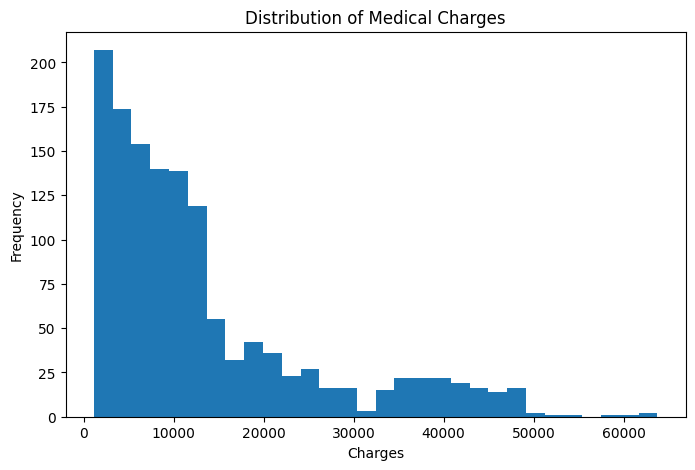

In [5]:
# 5) EDA Visualization 1: charges distribution
plt.figure(figsize=(8,5))
plt.hist(df["charges"], bins=30)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

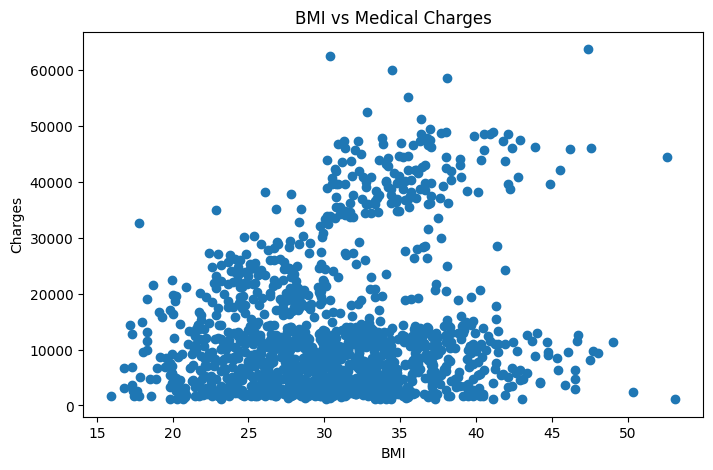

In [6]:
# 6) EDA Visualization 2: BMI vs Charges
plt.figure(figsize=(8,5))
plt.scatter(df["bmi"], df["charges"])
plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

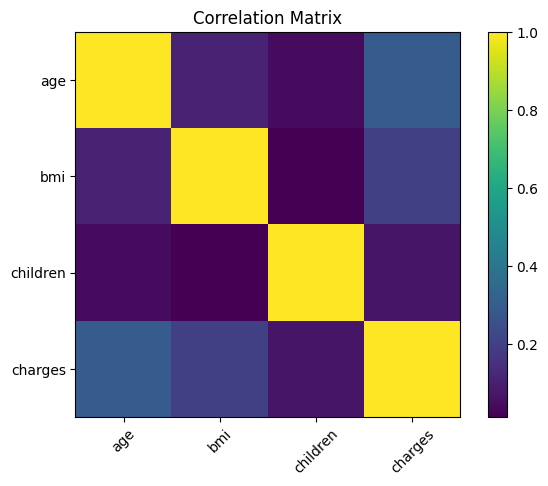

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


In [7]:
# 7) Optional: Correlation matrix for numeric columns
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(7,5))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

corr

In [8]:
# 8) Outlier check using IQR for charges
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["charges"] < lower_bound) | (df["charges"] > upper_bound)]
print("Number of outliers in charges:", len(outliers))
print("Upper bound:", upper_bound)

Number of outliers in charges: 139
Upper bound: 34524.777625


In [9]:
# 9) Split features and target
X = df.drop("charges", axis=1)
y = df["charges"]

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

In [10]:
# 10) Preprocessing: scaling + one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [11]:
# 11) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# 12) Baseline Linear Regression model
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R2:", linear_r2)

Linear Regression RMSE: 5956.342894363589
Linear Regression R2: 0.8069287081198011


In [13]:
# 13) Ridge Regularization with alpha tuning
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best CV RMSE:", -ridge_grid.best_score_)

Best Ridge alpha: {'model__alpha': 0.1}
Best CV RMSE: 6123.642087078248


In [14]:
# 14) Evaluate best Ridge model
best_ridge = ridge_grid.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R2:", ridge_r2)

Ridge Regression RMSE: 5957.879295748935
Ridge Regression R2: 0.8068290922101237


In [15]:
# 15) Optional: Lasso Regularization
lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

param_grid_lasso = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid_lasso,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_)
print("Best CV RMSE:", -lasso_grid.best_score_)

Best Lasso alpha: {'model__alpha': 10}
Best CV RMSE: 6121.873977606711


In [16]:
# 16) Final comparison table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "RMSE": [linear_rmse, ridge_rmse],
    "R2 Score": [linear_r2, ridge_r2]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,5956.342894,0.806929
1,Ridge Regression,5957.879296,0.806829
